In [ ]:
import xarray as xr

ds = xr.open_dataset("../data/raw/nclimgrid_tmax.nc")

print(ds)
print(ds.data_vars)

var_name = list(ds.data_vars)[0]
print("Using variable:", var_name)

first_month = ds[var_name].isel(time=0)
first_month.plot()

Using variable: tmax
Sub sizes: Frozen({'time': 5, 'lat': 155, 'lon': 192})
Lat range: 24.562532424926758 30.97920036315918
Lon range: -87.97916412353516 -80.02083587646484
<xarray.DataArray 'tmax' (time: 5, lat: 155, lon: 192)> Size: 595kB
[148800 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 40B 2026-01-01 2026-02-01 ... 2026-05-01
  * lat      (lat) float32 620B 30.98 30.94 30.9 30.85 ... 24.65 24.6 24.56
  * lon      (lon) float32 768B -87.98 -87.94 -87.9 ... -80.1 -80.06 -80.02
Attributes:
    references:     GHCN-Monthly Version 3 (Vose et al. 2011), NCEI/NOAA, htt...
    standard_name:  air_temperature
    units:          degree_Celsius
    valid_min:      -100.0
    valid_max:      100.0
    long_name:      Temperature, monthly average of daily maximums


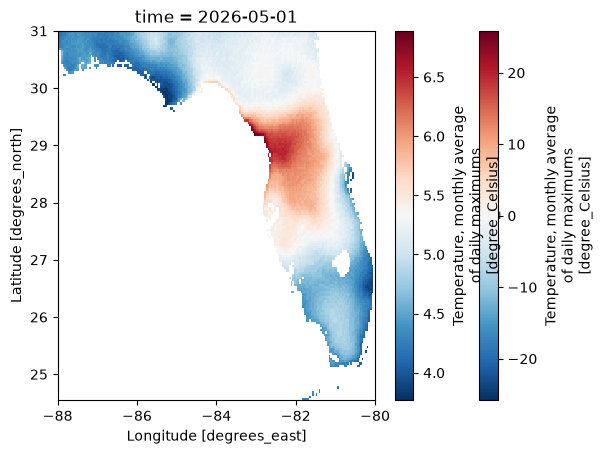

In [1]:
import xarray as xr

ds = xr.open_dataset("../data/raw/nclimgrid_tmax.nc")

var_name = list(ds.data_vars)[0]
print("Using variable:", var_name)

# Restrict to 2026 only
ds_2026 = ds.sel(time=slice("2026-01-01", "2026-12-31"))

# Grab and plot first available month in 2026
first_month_2026 = ds_2026[var_name].isel(time=0)
first_month_2026.plot()

# Rough bbox for Florida
# IMPORTANT: lat is descending in this dataset, so use slice(31, 24)
sub = ds_2026[var_name].sel(
    lat=slice(31, 24),
    lon=slice(-88, -80)
)

print("Sub sizes:", sub.sizes)
print("Lat range:", float(sub.lat.min()), float(sub.lat.max()))
print("Lon range:", float(sub.lon.min()), float(sub.lon.max()))
print(sub)

# Compare latest available 2026 month against 2026 mean so far
anomaly = sub.isel(time=-1) - sub.mean(dim="time")

anomaly.plot(cmap="RdBu_r")